<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/21_note.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Frechet Inception Distance (FID)

參考：
- [Stanford CS236: Deep Generative Models I 2023 I Lecture 15 - Evaluation of Generative Models](https://www.youtube.com/watch?v=MJt_ahtO-to&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=23)
- [GANs Trained by a Two Time-Scale Update Rule Converge to a Local Nash Equilibrium](https://arxiv.org/pdf/1706.08500)
- [Optimal Transport and Wasserstein Distance](https://www.stat.cmu.edu/~larry/=sml/Opt.pdf)
- [Stanford CS224W: ML with Graphs | 2021 | Lecture 15.3 - Scaling Up & Evaluating Graph Gen](https://www.youtube.com/watch?v=kDu5YY9d1TM&list=PLoROMvodv4rPLKxIpqhjhPgdQy7imNkDn&index=47)

Wasserstein distance
- $W_p(P,Q)=\left( \inf\limits_{J \in \mathcal{J}(P,Q)} \int\|x-y\|^p\ \text{d}J(x,y) \right)^{1/p}$
  - $\inf$: infimum (下確界)
  - $J$: joint distribution, transport plan
  - find the optimal transport plan

Wasserstein-1 distance or Earth Mover distance (EMD)
- Compare similarity between 2 distributions
- Intuition: Measure the minimum effort that move earth from  one pile to the other

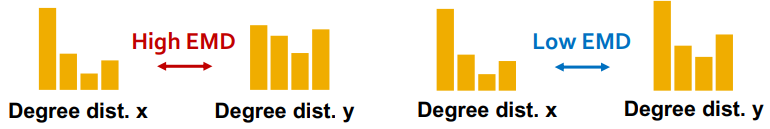

Wasserstein-2 distance or Fréchet distance
- $W_2(P,Q)^2=\inf\limits_{J \in \mathcal{J}(P,Q)} \int\|x-y\|^2\ \text{d}J(x,y)$

FID
- measures similarities in the feature representations for datapoints sampled from $p_\theta$ and the test dataset
- Computing:
  - Let $\mathcal{G}$ denote the generated samples and $\mathcal{T}$ denote the test dataset
  - Compute feature representations $F_\mathcal{G}$ and $F_\mathcal{T}$ for $\mathcal{G}$ and $\mathcal{T}$ respectively
  - Fit a multivariate Gaussian to each of $F_\mathcal{G}$ and $F_\mathcal{T}$. Let $(\mu_{\mathcal{G}},\Sigma_{\mathcal{G}})$ and
$(\mu_{\mathcal{T}},\Sigma_{\mathcal{T}})$ denote the mean and covariances of the two Gaussians
  - FID is defined as the Wasserstein-2 distance between these two
Gaussians:
    - $\|| \mu_{\mathcal{T}} - \mu_{\mathcal{G}} \||^2 + \text{Tr}\left( \Sigma_{\mathcal{T}}+\Sigma_{\mathcal{G}}-2(\Sigma_{\mathcal{T}}\Sigma_{\mathcal{G}})^{1/2} \right)$
- Lower FID implies better sample quality

## Kernel Inception Distance (KID)

參考：
- [Stanford CS236: Deep Generative Models I 2023 I Lecture 15 - Evaluation of Generative Models](https://www.youtube.com/watch?v=MJt_ahtO-to&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=23)
- [Stanford CS224W: ML with Graphs | 2021 | Lecture 15.3 - Scaling Up & Evaluating Graph Gen](https://www.youtube.com/watch?v=kDu5YY9d1TM&list=PLoROMvodv4rPLKxIpqhjhPgdQy7imNkDn&index=47)

Maximum Mean Discrepancy (MMD)
- representing distances between distributions as distances between mean embeddings of feature
- two-sample test statistic that compares samples from two distributions $p$ and $q$
- $\text{MMD}(p,q)^2=E_{x,x' \sim p}\left( K(x,x') \right)+E_{x,x' \sim q}\left( K(x,x') \right)-2E_{x \sim p,x' \sim q}\left( K(x,x') \right)$

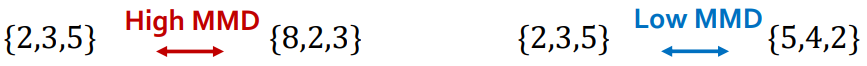

Radial Basis Function (RBF)
- $\displaystyle K(x,x')=\exp{\left( -\frac{\| x-x' \|_2^2}{2\sigma^2} \right)} \quad \text{where}\ \sigma \gt 0$

degree-$d$ polynomial
- $K(x,x')=(x^Tx'+c)^d \quad \text{where}\ c \ge 0$

KID
- compute the MMD in the feature space of a classifier (e.g., Inception Network)

FID vs. KID
- FID is biased (can only be positive), KID is unbiased
- FID can be evaluated in $O(n)$ time, KID evaluation requires $O(n^2)$ time

## Denoising Diffusion Implicit Models (DDIM)

參考：
- [Denoising Diffusion Implicit Models (DDIM) Explained](https://www.youtube.com/watch?v=n2P6EMbN0pc)
- [paper: Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)

#### DDPM

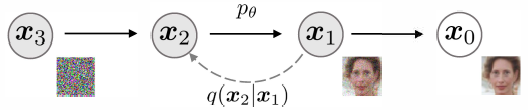

- diffusion process: $q(x_{1:T} \mid x_0)=\prod\limits_{t=1}^Tq(x_t \mid x_{t-1})$

- DDPM objective only depends on the marginals $q(x_t \mid x_0)=\mathcal{N}\left(\sqrt{\bar{\alpha}_t}x_0,(1-\bar{\alpha}_t)I \right)$, but not directly on the joint $q(x_{1:T} \mid x_0)$.

#### DDIM

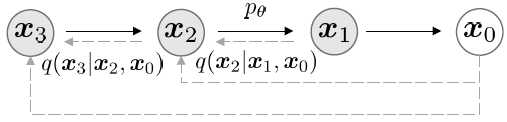

- inference distribution: $\displaystyle q_\sigma(x_{t-1} \mid x_t,x_0)=\mathcal{N}\left( \sqrt{\alpha_{t-1}}x_0 + \sqrt{1-\alpha_{t-1}-\sigma_t^2} \frac{x_t-\sqrt{\alpha_t}x_0}{\sqrt{1-\alpha_t}},\sigma_t^2I \right)$
- diffusion process: $q_\sigma(x_{1:T} \mid x_0)=q_\sigma(x_T \mid x_0)\prod\limits_{t=2}^Tq_\sigma(x_{t-1} \mid x_t,x_0)$

- same objective as DDPM

non-markovian diffusion process
- $\displaystyle q_\sigma(x_t \mid x_{t-1},x_0)=\frac{q_\sigma(x_{t-1} \mid x_t,x_0)q_\sigma(x_t \mid x_0)}{q_\sigma(x_{t-1} \mid x_0)}$
- the magnitude of $\sigma$ controls the how stochastic the forward process
is
  - $\sigma=0$: deterministic

- implicit probabilistic model trained with the DDPM objective (despite the forward process no longer being a diffusion)

generative process:

<img src="">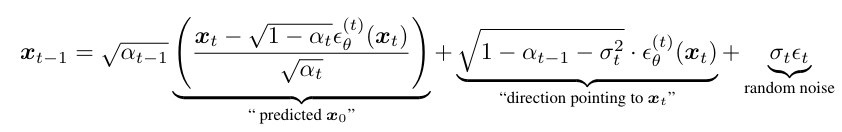

- $\sigma_t=\sqrt{1-\alpha_{t-1}/(1-\alpha_t)}\sqrt{1-\alpha_t/\alpha_{t-1}}$
  - the generative process becomes a DDPM

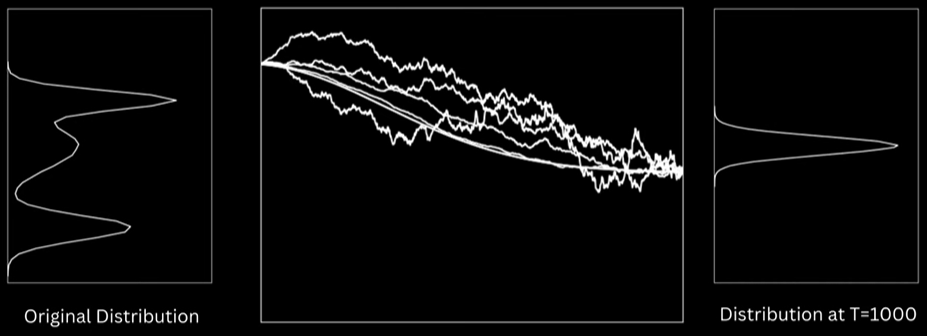

vs. DDPM skip sampling
- DDPM sampling has a higher variance noise added at each step so the stochasticity of the trajectory makes it harder for larger jumps
- we could simply reduce the variance at sampling time in DDPM but that will lead you to a poor approximation of the reverse process
- with the reformulated mean of DDIM coming from a generalized non-markovian process we have changed the trajectory itself making it completely deterministic for sigma equals 0 which allows us to make these large jumps

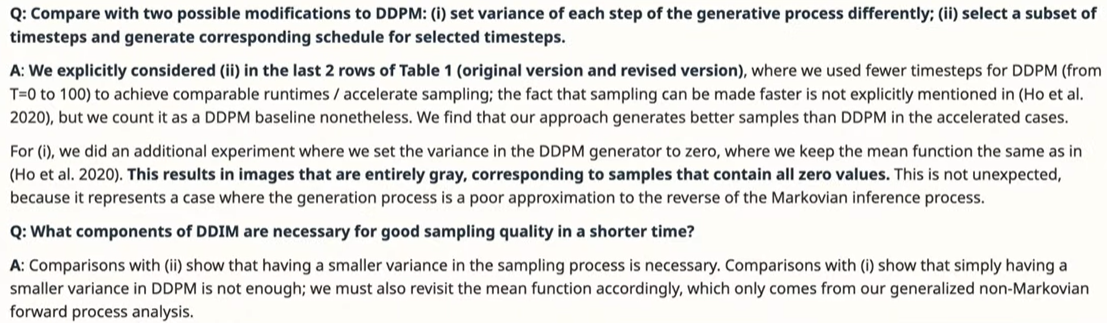

## 影片的 colab

- [21_cifar10_and_wandb.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/21_cifar10_and_wandb.ipynb)
- [18_fid.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/18_fid.ipynb)
- [19_DDPM_v3.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/19_DDPM_v3.ipynb#scrollTo=2ab0c11d)
- [20_DDIM.ipynb](https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/20_DDIM.ipynb)